### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
import pandas as pd
import numpy as np

raw_df = pd.read_csv('marketing_campaign.csv', delimiter='\t')

raw_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [2]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

З виведеної інформації бачимо, що всі колонки є числовими, за винятком двох категоріальних колонок і однієї колонки з датою.
Пропущені значення є лише в колонці Income

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

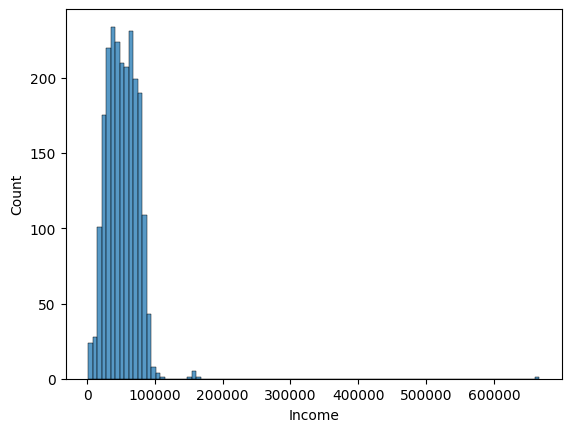

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data = raw_df, x = 'Income', bins=100)
plt.show()

raw_df['Income'].describe()

Розподіл прямує до нормального, але скошений вправо за рахунок викидів. Для кластеризації я би краще забрала викиди і замінила їх та пропущені значення медіаною, бо вона стійкіша до аноманій.
Бачу, що викиди будемо видаляти пізніше в ДЗ, тому тут поки не робитиму, подивлюся на різницю в результатах

In [4]:
raw_df['Income'].fillna(raw_df['Income'].median(), inplace = True)
raw_df.isna().values.sum()

/var/folders/n1/kks48gjd1cbgnz7hvhbm8w9w0000gn/T/ipykernel_1455/3641019214.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_df['Income'].fillna(raw_df['Income'].median(), inplace = True)


np.int64(0)

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [5]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

to_oh_encoder = ['Marital_Status']

oh_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(raw_df[to_oh_encoder])
encoded_oh = list(oh_encoder.get_feature_names_out(to_oh_encoder))
raw_df[encoded_oh] = oh_encoder.transform(raw_df[to_oh_encoder])

to_ord_encoder = ['Education']
education_order = [['Basic', 'Graduation', '2n Cycle', 'Master', 'PhD']]
ord_encoder = OrdinalEncoder(categories=education_order).fit(raw_df[to_ord_encoder])
encoded_ord = [col + '_Encoded' for col in to_ord_encoder]
raw_df[encoded_ord] = ord_encoder.transform(raw_df[to_ord_encoder])

In [6]:
dt_cust_col = 'Dt_Customer'
raw_df[dt_cust_col] = pd.to_datetime(raw_df[dt_cust_col], dayfirst=True, errors='coerce')
raw_df[dt_cust_col].isnull().any()

np.False_

In [7]:
max_date = raw_df[dt_cust_col].max()
raw_df['Customer_Days'] = (max_date - raw_df[dt_cust_col]).dt.days

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [8]:
# наступні колонки скоріш за все містять константи, перевірила це
z_cols = ['Z_CostContact', 'Z_Revenue']
for col in z_cols:
    display(raw_df[col].value_counts())

Z_CostContact
3    2240
Name: count, dtype: int64

Z_Revenue
11    2240
Name: count, dtype: int64

In [9]:
# ради інтересу пробувала замінити всі покупки їх сумою, але покращення це не дало
#mnt_cols = ['MntFishProducts', 'MntFruits', 'MntGoldProds', 'MntMeatProducts', 'MntSweetProducts', 'MntWines']
#raw_df['TotalMnt'] = raw_df[mnt_cols].sum(axis=1)

cols_for_analysis = raw_df.columns.difference(to_oh_encoder + to_ord_encoder + [dt_cust_col] + ['ID'] + z_cols)

X = raw_df[cols_for_analysis].copy()

In [10]:
from sklearn.cluster import KMeans
from sklearn import metrics

kmeans_1 = KMeans(n_clusters=3, n_init='auto', random_state=10)
kmeans_1.fit(X)

labels_1 = kmeans_1.predict(X)

s_1 = metrics.silhouette_score(X, labels_1, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s_1:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.54


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

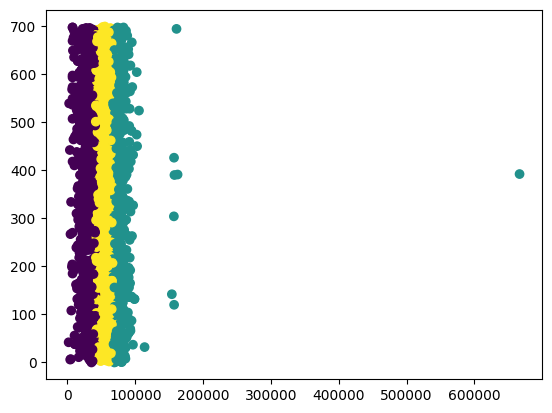

In [11]:
plt.scatter(X['Income'], X['Customer_Days'], c=labels_1)
plt.show()

In [12]:
import plotly.express as px
fig = px.scatter_3d(X, x='Income', y='MntMeatProducts', z='Customer_Days',
              color=labels_1)
fig.show()

Які б метрики я не вказувала разом з Income, видно що кластеризація відбувається переважно по ознаці Income, а інші не враховуються. Це пов'язано із тим, що ця колонка містить на порядок більші значення, ніж інші, тому найбільше впливає на результат. Для того щоб "вирівняти" всі ознаки, потрібно масштабувати дані

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Complain,Customer_Days,Education_Encoded,Income,Kidhome,...,MntWines,NumCatalogPurchases,NumDealsPurchases,NumStorePurchases,NumWebPurchases,NumWebVisitsMonth,Recency,Response,Teenhome,Year_Birth
0,0.0,0.0,0.0,0.0,0.0,0.0,0.948498,0.25,0.084832,0.0,...,0.425318,0.357143,0.200000,0.307692,0.296296,0.35,0.585859,1.0,0.0,0.621359
1,0.0,0.0,0.0,0.0,0.0,0.0,0.161660,0.25,0.067095,0.5,...,0.007368,0.035714,0.133333,0.153846,0.037037,0.25,0.383838,0.0,0.5,0.592233
2,0.0,0.0,0.0,0.0,0.0,0.0,0.446352,0.25,0.105097,0.0,...,0.285332,0.071429,0.066667,0.769231,0.296296,0.20,0.262626,0.0,0.0,0.699029
3,0.0,0.0,0.0,0.0,0.0,0.0,0.198856,0.25,0.037471,0.5,...,0.007368,0.000000,0.133333,0.307692,0.074074,0.30,0.262626,0.0,0.0,0.883495
4,0.0,0.0,0.0,0.0,0.0,0.0,0.230329,1.00,0.085065,0.5,...,0.115874,0.107143,0.333333,0.461538,0.185185,0.25,0.949495,0.0,0.0,0.854369


In [14]:
kmeans_2 = KMeans(n_clusters=3, n_init='auto', random_state=10)
kmeans_2.fit(X_scaled)

labels_2 = kmeans_2.predict(X_scaled)

s_2 = metrics.silhouette_score(X_scaled, labels_2, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s_2:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.24


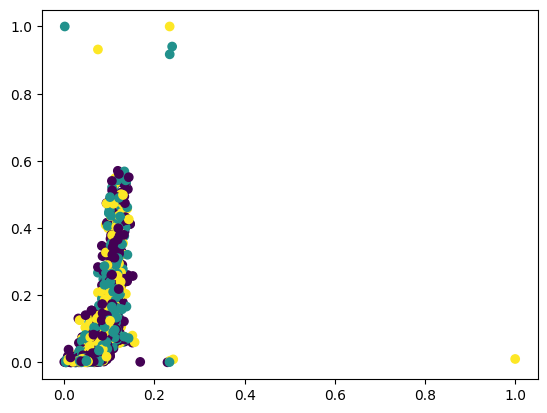

In [15]:
plt.scatter(X_scaled['Income'], X_scaled['MntMeatProducts'], c=labels_2)
plt.show()

In [16]:
fig = px.scatter_3d(X_scaled, x='Income', y='MntMeatProducts', z='Customer_Days',
              color=labels_2)
fig.show()

Метрика силуату значно знизилась, і кластери вже не такі чіткі, як раніше (точніше, їх в принципі не видно). Це було очікувано після масштабування доходу - також можливо ознак забагато і вони заназто розріджені і варто пооб'єднувати кілька ознак в одну

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [17]:
# в raw_df ми не масштабували дані
Q1 = raw_df['Income'].quantile(0.25)
Q3 = raw_df['Income'].quantile(0.75)

lower_bound = Q1 - 1.5 * (Q3 - Q1)
upper_bound = Q3 + 1.5 * (Q3 - Q1)

outliers = raw_df[(raw_df['Income'] < lower_bound) | (raw_df['Income'] > upper_bound)]
print(f"Income acceptable range: {lower_bound:.2f} to {upper_bound:.2f}")
print(f"Number of outliers found: {len(outliers)} rows out of {len(raw_df)}")

raw_df['Income'] = raw_df['Income'].where((raw_df['Income'] >= lower_bound) & (raw_df['Income'] <= upper_bound), np.nan)
raw_df['Income'] = raw_df['Income'].fillna(raw_df['Income'].median())

income_scaled_array = scaler.fit_transform(raw_df[['Income']])
X_scaled['Income'] = pd.Series(income_scaled_array.flatten(), index=X_scaled.index)


Income acceptable range: -13587.75 to 117416.25
Number of outliers found: 8 rows out of 2240


Silhouette Coefficient for the data Dataset Clusters: 0.24


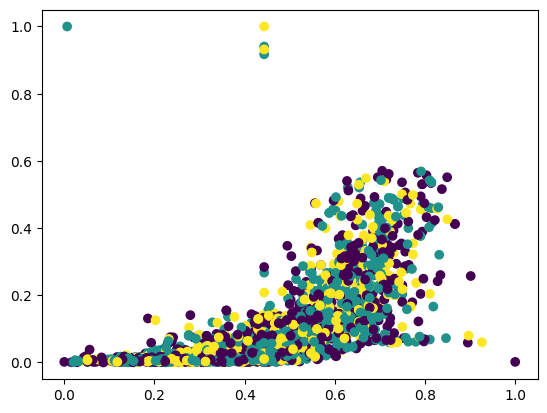

In [18]:
kmeans_3 = KMeans(n_clusters=3, n_init='auto', random_state=10)
kmeans_3.fit(X_scaled)

labels_3 = kmeans_3.predict(X_scaled)

s_3 = metrics.silhouette_score(X_scaled, labels_3, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s_3:.2f}')
plt.scatter(X_scaled['Income'], X_scaled['MntMeatProducts'], c=labels_3)
plt.show()

In [19]:
fig = px.scatter_3d(X_scaled, x='Income', y='MntMeatProducts', z='NumCatalogPurchases',
              color=labels_3)
fig.show()

Ситуація не змінилась, просто візуально видно, що дані вєе без викидів по осі Income

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

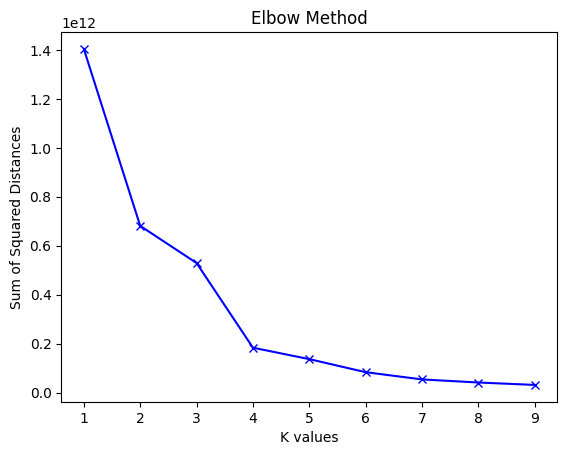

In [20]:
K = range(1,10)
sum_of_squared_distances = []

for k in K:
    model = KMeans(n_clusters=k, n_init='auto', random_state=10).fit(X)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method')
plt.show()

Silhouette Coefficient for the data Dataset Clusters: 0.27


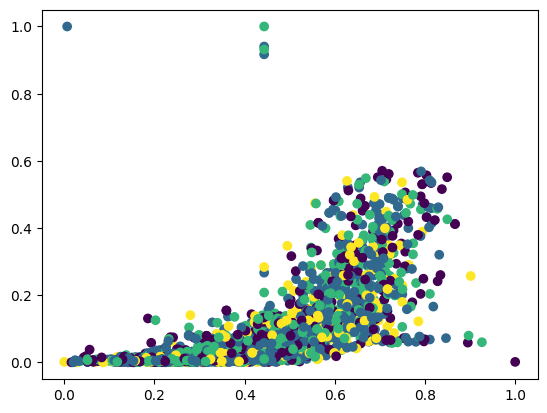

In [21]:
kmeans_4 = KMeans(n_clusters=4, n_init='auto', random_state=10)
kmeans_4.fit(X_scaled)

labels_4 = kmeans_4.predict(X_scaled)

centroids_4 = kmeans_4.cluster_centers_
s_4 = metrics.silhouette_score(X_scaled, labels_4, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s_4:.2f}')
plt.scatter(X_scaled['Income'], X_scaled['MntMeatProducts'], c=labels_4)
plt.show()

In [22]:
fig = px.scatter_3d(X_scaled, x='Income', y='MntMeatProducts', z='Customer_Days',
              color=labels_4)
fig.show()

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

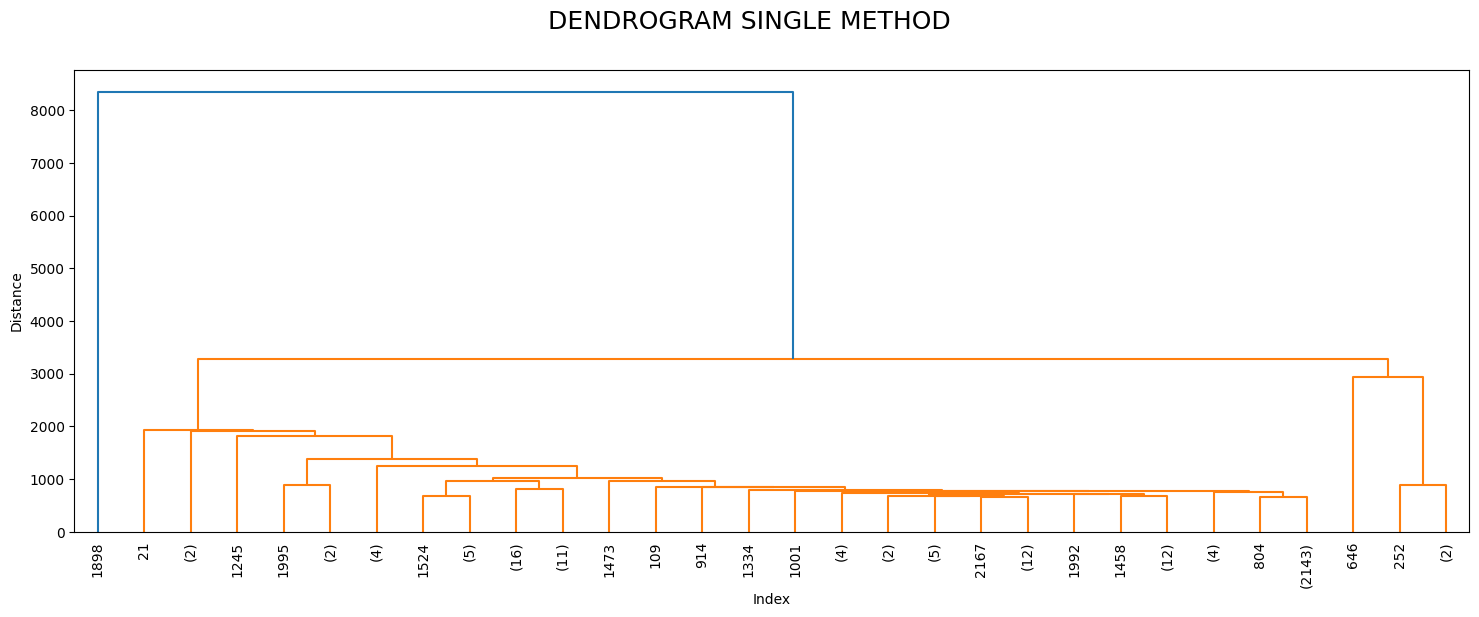

Silhouette Coefficient for 2 Clusters: 0.56
Silhouette Coefficient for 3 Clusters: 0.45


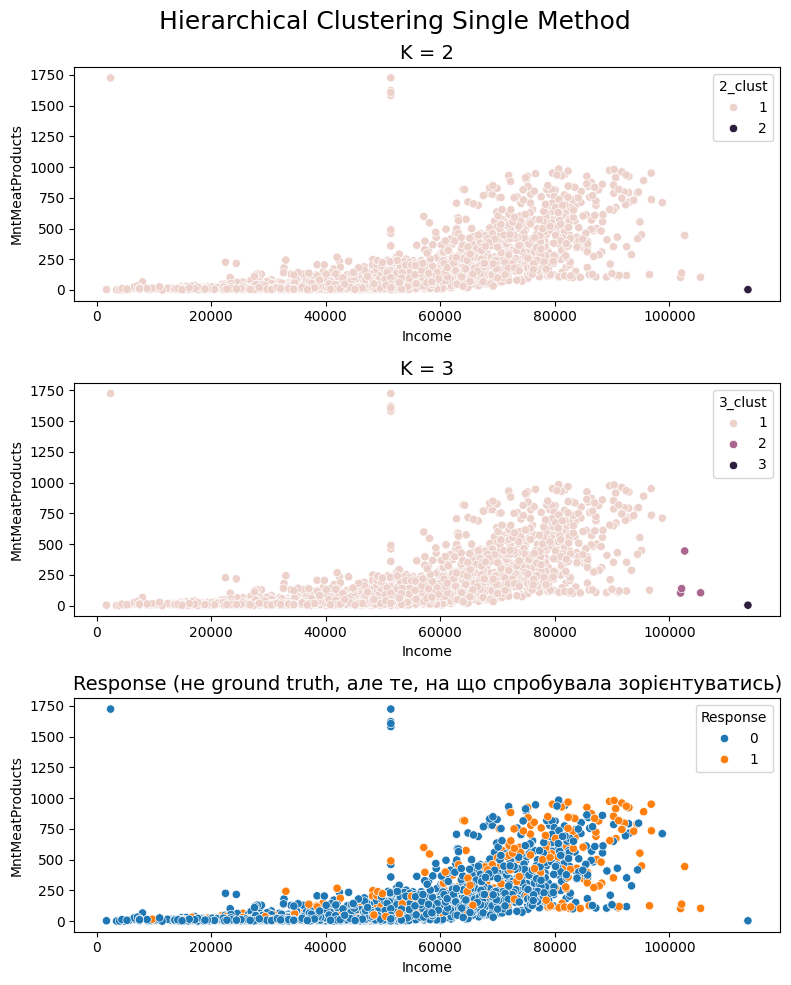

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import seaborn as sns

# в raw_df дані не відмасштабовані, але без викидів по Income
X_wo_outliers = raw_df[cols_for_analysis].copy()

# винесла в окрему функцію, так як буду використовувати кілька разів
def clusterization_hierarchical(X, method="single"):
    dist_sin = linkage(X, method)
    plt.figure(figsize=(18,6))
    dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
    plt.xlabel('Index')
    plt.ylabel('Distance')
    plt.suptitle(f"DENDROGRAM {method.upper()} METHOD",fontsize=18)
    plt.show()
    X['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
    X['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')
    
    s_2 = metrics.silhouette_score(X, X['2_clust'], metric='euclidean')
    print(f'Silhouette Coefficient for 2 Clusters: {s_2:.2f}')
    
    s_3 = metrics.silhouette_score(X, X['3_clust'], metric='euclidean')
    print(f'Silhouette Coefficient for 3 Clusters: {s_3:.2f}')

    plt.figure(figsize=(8,10))
    plt.suptitle(f"Hierarchical Clustering {method.capitalize()} Method",fontsize=18)
    
    plt.subplot(3,1,1)
    plt.title("K = 2",fontsize=14)
    sns.scatterplot(x="Income",y="MntMeatProducts", data=X, hue="2_clust")
    
    plt.subplot(3,1,2)
    plt.title("K = 3",fontsize=14)
    sns.scatterplot(x="Income",y="MntMeatProducts", data=X, hue="3_clust")
    
    plt.subplot(3,1,3)
    plt.title("Response (не ground truth, але те, на що спробувала зорієнтуватись)", fontsize=14)
    sns.scatterplot(x="Income", y="MntMeatProducts", data=X, hue='Response')
    plt.tight_layout();

clusterization_hierarchical(X_wo_outliers)

Все ще погані результати. На перший двох графіках видно, що все одно по Income кластеризує, але поганенько. В окремі дуже малі кластери попадають викиди, а все решта збивається в один величезний кластер. Це ж саме видно і по дендрограмі - бачимо там фактично одну велику групу (2143) і поодинокі точки та маленькі кластери
(Responce хоч і не ground truth, але вирішила для цікавості провізуалізувати)
Метрика силуету непогана, але мабуть через те, що в окремі кластери попали викиди, які далеко від основних значень

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

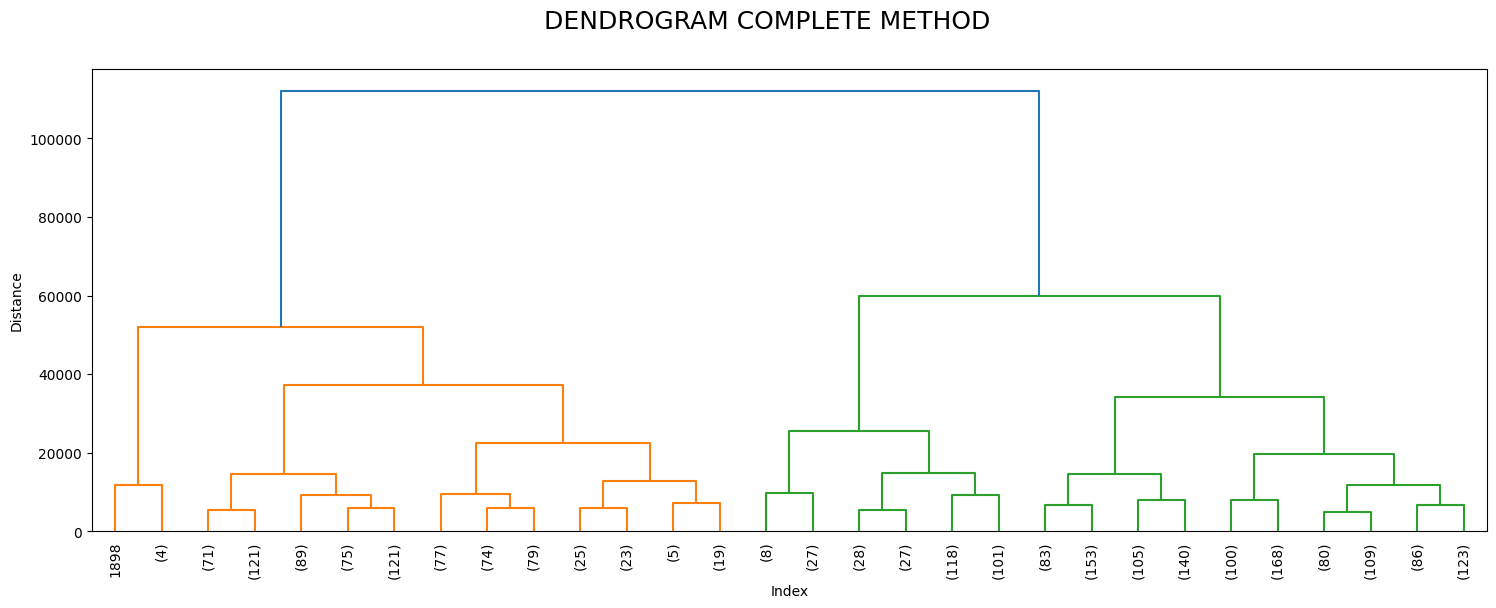

Silhouette Coefficient for 2 Clusters: 0.56
Silhouette Coefficient for 3 Clusters: 0.50


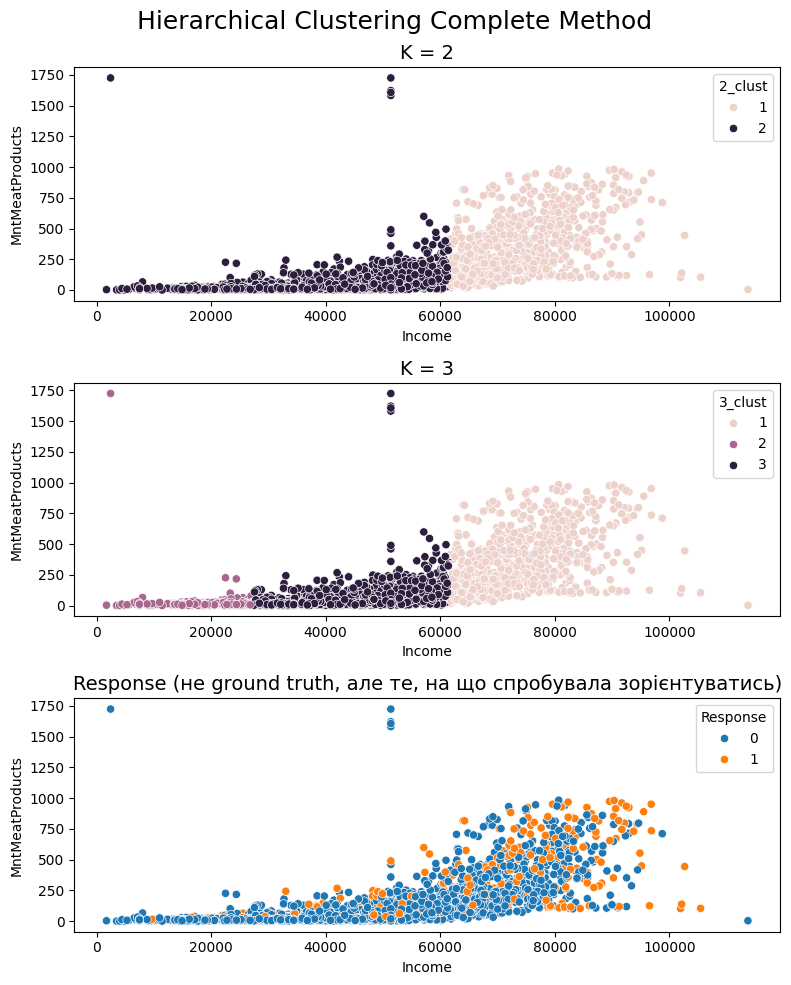

In [24]:
clusterization_hierarchical(X_wo_outliers, "complete")

Linkage 'complete', 'average', 'ward' показали себе приблизно однаково - результат хороший для k=3, але враховуючи, що дані непромасштабовані, то кластеризація відбувається за ознакою Income

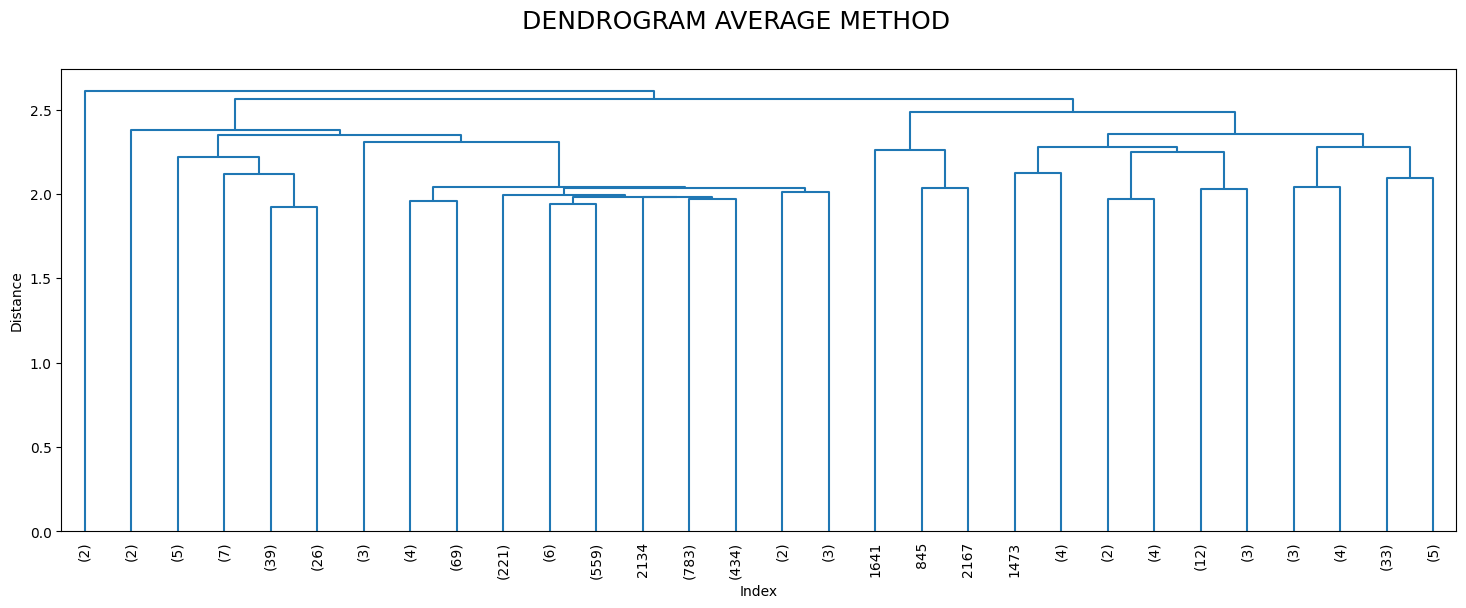

Silhouette Coefficient for 2 Clusters: 0.36
Silhouette Coefficient for 3 Clusters: 0.32


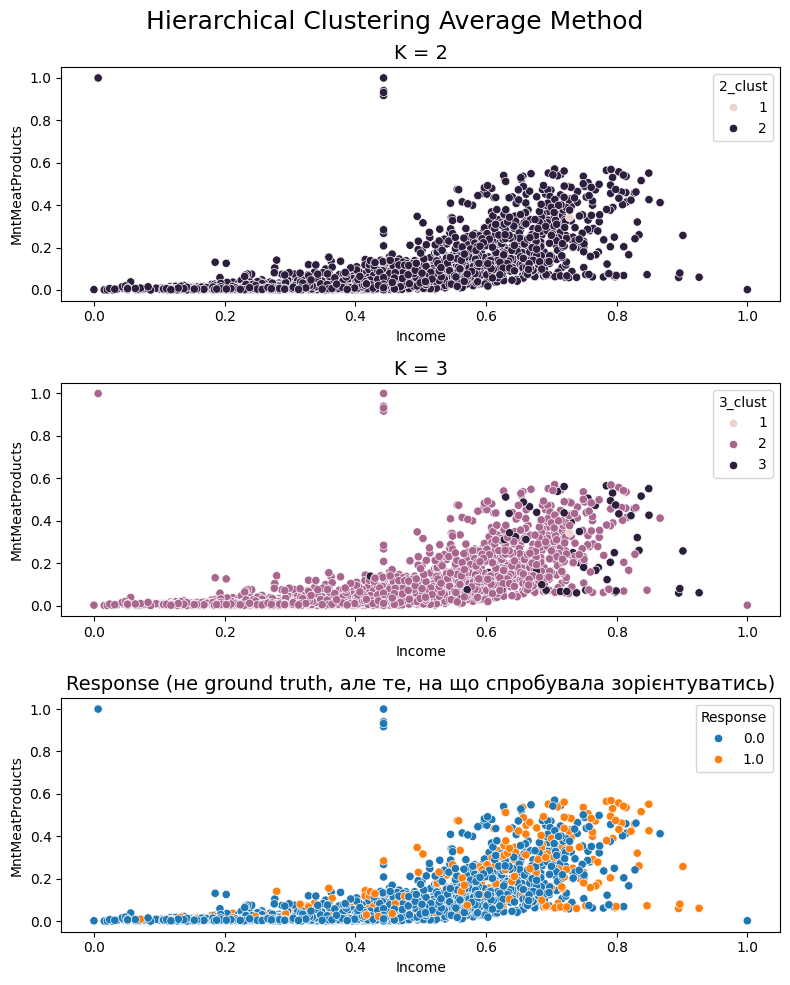

In [25]:
clusterization_hierarchical(X_scaled, "average")

Спробувала також на відмасштабованих даних - забравши вплив Income, знову отримуємо щось хаотичне і не дуже зрозуміле. Мені здається тут треба більше дослідити самі ознаки за допомогою EDA, можливо не всі є значущими і викидання деяких із них (або створення нових фіч на основі існуючих) могло би покращити результат. Але в межах цього ДЗ вже не встигаю це зробити.